# Homework 6

## References

+ Lectures 21-23 (inclusive).


## Instructions

+ Type your name and email in the "Student details" section below.
+ Develop the code and generate the figures you need to solve the problems using this notebook.
+ For the answers that require a mathematical proof or derivation you should type them using latex. If you have never written latex before and you find it exceedingly difficult, we will likely accept handwritten solutions.
+ The total homework points are 100. Please note that the problems are not weighed equally.

If on Google Colab, install the following packages:

In [6]:
MAKE_BOOK_FIGURES=True
import numpy as np
import scipy.stats as st

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns
sns.set_context("paper")
sns.set_style("ticks")

def set_book_style():
    plt.style.use('seaborn-v0_8-white') 
    sns.set_style("ticks")
    sns.set_palette("deep")

    mpl.rcParams.update({
        # Font settings
        'font.family': 'serif',  # For academic publishing
        'font.size': 8,  # As requested, 10pt font
        'axes.labelsize': 8,
        'axes.titlesize': 8,
        'xtick.labelsize': 7,  # Slightly smaller for better readability
        'ytick.labelsize': 7,
        'legend.fontsize': 7,
        
        # Line and marker settings for consistency
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'lines.markersize': 4,
        
        # Layout to prevent clipped labels
        'figure.constrained_layout.use': True,
        
        # Default DPI (will override when saving)
        'figure.dpi': 600,
        'savefig.dpi': 600,
        
        # Despine - remove top and right spines
        'axes.spines.top': False,
        'axes.spines.right': False,
        
        # Remove legend frame
        'legend.frameon': False,
        
        # Additional trim settings
        'figure.autolayout': True,  # Alternative to constrained_layout
        'savefig.bbox': 'tight',    # Trim when saving
        'savefig.pad_inches': 0.1   # Small padding to ensure nothing gets cut off
    })

def set_notebook_style():
    plt.style.use('seaborn-v0_8-white')
    sns.set_style("ticks")
    sns.set_palette("deep")

    mpl.rcParams.update({
        # Font settings - using default sizes
        'font.family': 'serif',
        'axes.labelsize': 10,
        'axes.titlesize': 10,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        
        # Line and marker settings
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'lines.markersize': 4,
        
        # Layout settings
        'figure.constrained_layout.use': True,
        
        # Remove only top and right spines
        'axes.spines.top': False,
        'axes.spines.right': False,
        
        # Remove legend frame
        'legend.frameon': False,
        
        # Additional settings
        'figure.autolayout': True,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1
    })

def save_for_book(fig, filename, is_vector=True, **kwargs):
    """
    Save a figure with book-optimized settings.
    
    Parameters:
    -----------
    fig : matplotlib figure
        The figure to save
    filename : str
        Filename without extension
    is_vector : bool
        If True, saves as vector at 1000 dpi. If False, saves as raster at 600 dpi.
    **kwargs : dict
        Additional kwargs to pass to savefig
    """    
    # Set appropriate DPI and format based on figure type
    if is_vector:
        dpi = 1000
        ext = '.pdf'
    else:
        dpi = 600
        ext = '.tif'
    
    # Save the figure with book settings
    fig.savefig(f"{filename}{ext}", dpi=dpi, **kwargs)

def make_full_width_fig():
    return plt.subplots(figsize=(4.7, 2.9), constrained_layout=True)

def make_half_width_fig():
    return plt.subplots(figsize=(2.35, 1.45), constrained_layout=True)

if MAKE_BOOK_FIGURES:
    set_book_style()
else:
    set_notebook_style()

make_full_width_fig = make_full_width_fig if MAKE_BOOK_FIGURES else lambda: plt.subplots()
make_half_width_fig = make_half_width_fig if MAKE_BOOK_FIGURES else lambda: plt.subplots()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
import torch, gpytorch
from gpytorch.kernels import ScaleKernel, RBFKernel
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns
sns.set_context("paper")
sns.set_style("ticks")

import scipy
import scipy.stats as st
import urllib.request
import os

def download(
    url : str,
    local_filename : str = None
):
    """Download a file from a url.
    
    Arguments
    url            -- The url we want to download.
    local_filename -- The filemame to write on. If not
                      specified 
    """
    if local_filename is None:
        local_filename = os.path.basename(url)
    urllib.request.urlretrieve(url, local_filename)

def sample_functions(mean_func, kernel_func, num_samples=10, num_test=100, nugget=1e-3):
    """Sample functions from a Gaussian process.

    Arguments:
        mean_func -- the mean function. It must be a callable that takes a tensor
            of shape (num_test, dim) and returns a tensor of shape (num_test, 1).
        kernel_func -- the covariance function. It must be a callable that takes
            a tensor of shape (num_test, dim) and returns a tensor of shape
            (num_test, num_test).
        num_samples -- the number of samples to take. Defaults to 10.
        num_test -- the number of test points. Defaults to 100.
        nugget -- a small number required for stability. Defaults to 1e-5.
    """
    X = torch.linspace(0, 1, num_test)[:, None]
    m = mean_func(X)
    C = kernel_func.forward(X, X) + nugget * torch.eye(X.shape[0])
    L = torch.linalg.cholesky(C)
    fig, ax = plt.subplots()
    ax.plot(X, m.detach(), label='mean')
    for i in range(num_samples):
        z = torch.randn(X.shape[0], 1) 
        f = m[:, None] + L @ z  
        ax.plot(X.flatten(), f.detach().flatten(), color=sns.color_palette()[1], linewidth=0.5, 
                label='sample' if i == 0 else None
            )
    plt.legend(loc='best', frameon=False)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_ylim(-5, 5)
    sns.despine(trim=True);


import gpytorch

class ExactGP(gpytorch.models.ExactGP):
    def __init__(self,
                 train_x,
                 train_y,
                 likelihood=gpytorch.likelihoods.GaussianLikelihood(),
                mean_module=gpytorch.means.ConstantMean(),
                covar_module=ScaleKernel(RBFKernel())
        ):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = mean_module
        self.covar_module = covar_module

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


def plot_1d_regression(
    x_star,
    model,
    ax=None,
    f_true=None,
    num_samples=10,
    xlabel='$x$',
    ylabel='$y$'
):
    """Plot the posterior predictive.
    
    Arguments
    x_start  --  The test points on which to evaluate.
    model    --  The trained model.
    
    Keyword Arguments
    ax          --  An axes object to write on.
    f_true      --  The true function.
    num_samples --  The number of samples.
    xlabel      --  The x-axis label.
    ylabel      --  The y-axis label.
    """
    f_star = model(x_star)
    m_star = f_star.mean
    v_star = f_star.variance
    y_star = model.likelihood(f_star)
    yv_star = y_star.variance

    f_lower = (
        m_star - 2.0 * torch.sqrt(v_star)
    )
    f_upper = (
        m_star + 2.0 * torch.sqrt(v_star)
    )
    
    y_lower = m_star - 2.0 * torch.sqrt(yv_star)
    y_upper = m_star + 2.0 * torch.sqrt(yv_star)

    if ax is None:
        fig, ax = plt.subplots()
    
    ax.plot(model.train_inputs[0].flatten().detach(),
            model.train_targets.detach(),
            'k.',
            markersize=1,
            markeredgewidth=2,
            label='Observations'
    )

    ax.plot(
        x_star,
        m_star.detach(),
        lw=2,
        label='Posterior mean',
        color=sns.color_palette()[0]
    )
    
    ax.fill_between(
        x_star.flatten().detach(),
        f_lower.flatten().detach(),
        f_upper.flatten().detach(),
        alpha=0.5,
        label='Epistemic uncertainty',
        color=sns.color_palette()[0]
    )

    ax.fill_between(
        x_star.detach().flatten(),
        y_lower.detach().flatten(),
        f_lower.detach().flatten(),
        color=sns.color_palette()[1],
        alpha=0.5,
        label='Aleatory uncertainty'
    )
    ax.fill_between(
        x_star.detach().flatten(),
        f_upper.detach().flatten(),
        y_upper.detach().flatten(),
        color=sns.color_palette()[1],
        alpha=0.5,
        label=None
    )

    
    if f_true is not None:
        ax.plot(
            x_star,
            f_true(x_star),
            'm-.',
            label='True function'
        )
        
    if num_samples > 0:
        f_post_samples = f_star.sample(
            sample_shape=torch.Size([10])
        )
        ax.plot(
            x_star.numpy(),
            f_post_samples.T.detach().numpy(),
            color="red",
            lw=0.5
        )
        # This is just to add the legend entry
        ax.plot(
            [],
            [],
            color="red",
            lw=0.5,
            label="Posterior samples"
        )
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    plt.legend(loc='best', frameon=False)
    sns.despine(trim=True)
    
    return dict(m_star=m_star, v_star=v_star, ax=ax)


def train(model, train_x, train_y, n_iter=10, lr=0.1):
    """Train the model.

    Arguments
    model   --  The model to train.
    train_x --  The training inputs.
    train_y --  The training labels.
    n_iter  --  The number of iterations.
    """
    model.train()
    optimizer = torch.optim.LBFGS(model.parameters(), line_search_fn='strong_wolfe')
    likelihood = model.likelihood
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    def closure():
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        print(loss)
        return loss
    for i in range(n_iter):
        loss = optimizer.step(closure)
        if (i + 1) % 1 == 0:
            print(f'Iter {i + 1:3d}/{n_iter} - Loss: {loss.item():.3f}')
    model.eval()


## Student details

+ **First Name:**Riad   
+ **Last Name:**Fikani 
+ **Email:**rfikani@purdue.edu

## Problem 1 - Defining priors on function spaces

In this problem, we will explore further how Gaussian processes can be used to define probability measures over function spaces.
To this end, assume that there is a 1D function, call if $f(x)$, which we do not know.
For simplicity, assume that $x$ takes values in $[0,1]$.
We will employ Gaussian process regression to encode our state of knowledge about $f(x)$ and sample some possibilities.
For each of the cases below:
+ Assume that $f\sim \operatorname{GP}(m, k)$ and pick a mean ($m(x)$) and a covariance function $f(x)$ that match the provided information.
+ Write code that samples a few times (up to five) the values of $f(x)$ at 100 equidistant points between 0 and 1.

### Part A - Super smooth function with known length scale

Assume that you hold the following beliefs
+ You know that $f(x)$ has as many derivatives as you want and they are all continuous
+ You don't know if $f(x)$ has a specific trend.
+ You think that $f(x)$ has "wiggles" that are approximatly of size $\Delta x=0.1$.
+ You think that $f(x)$ is between -4 and 4.

**Answer:**

**I am doing this for you so that you have a concrete example of what is requested.**

The mean function should be:

$$
m(x) = 0.
$$

The covariance function should be a squared exponential:

$$
k(x,x') = s^2\exp\left\{-\frac{(x-x')^2}{2\ell^2}\right\},
$$

with variance:

$$
s^2 = k(x,x) = \mathbb{V}[f(x)] = 4,
$$

and lengthscale $\ell = 0.1$.
We chose the variance to be 4.0 so that with (about) 95% probability, the values of $f(x)$ are between -4 and 4.

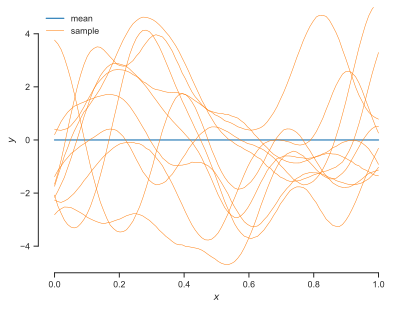

In [ ]:
import torch
import gpytorch
from gpytorch.kernels import RBFKernel, ScaleKernel

# Define the covariance function
k = ScaleKernel(RBFKernel())
k.outputscale = 4.0
k.base_kernel.lengthscale = 0.1

# Define the mean function
mean = gpytorch.means.ConstantMean()
mean.constant = 0.0

# Sample functions
sample_functions(mean, k, nugget=1e-4)

### Part B - Super smooth function with known ultra-small length scale

Assume that you hold the following beliefs
+ You know that $f(x)$ has as many derivatives as you want and they are all continuous
+ You don't know if $f(x)$ has a specific trend.
+ You think that $f(x)$ has "wiggles" that are approximatly of size $\Delta x=0.05$.
+ You think that $f(x)$ is between -3 and 3.

**Answer:**

we assume $f\sim\mathcal{GP}(m,k)$. Since the function is infinitely differentiable, we choose a squared‑exponential (RBF) covariance; the “wiggle” size $\Delta x\approx 0.05$ sets the length scale; no trend implies a zero mean. To keep values in $[-3,3]$ with about $95\%$ probability, we set the prior variance accordingly.

Mean:

$$
m(x)=0.
$$

Covariance:

$$
k(x,x') \;=\; s^{2}\exp\!\left(-\frac{(x-x')^{2}}{2\ell^{2}}\right),
\qquad \ell = 0.05.
$$

Variance choice (derivation):

$$
f(x)\sim\mathcal{N}\!\left(0,\,s^{2}\right)
\;\Longrightarrow\;
\mathbb{P}\big(|f(x)|\le 2s\big)\approx 0.95.
$$

$$
\text{Require } |f(x)|\lesssim 3 \text{ with }95\%\Rightarrow 2s=3
\;\Longrightarrow\;
s=\tfrac{3}{2},\quad s^{2}=\left(\tfrac{3}{2}\right)^{2}=\tfrac{9}{4}=2.25.
$$

Thus,

$$
k(x,x') \;=\; 2.25\,\exp\!\left(-\frac{(x-x')^{2}}{2(0.05)^{2}}\right), 
\qquad 
k(x,x)=\operatorname{Var}[f(x)]=2.25.
$$

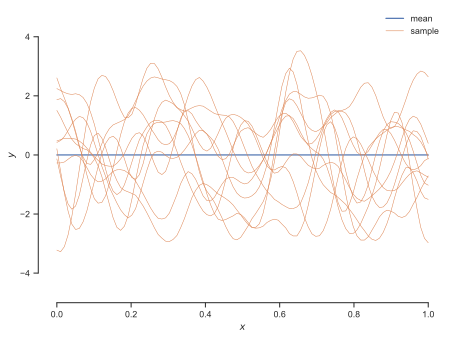

In [13]:
import torch
import gpytorch
from gpytorch.kernels import RBFKernel, ScaleKernel

k = ScaleKernel(RBFKernel())
k.outputscale = 2.25
k.base_kernel.lengthscale = 0.05

mean = gpytorch.means.ConstantMean()
mean.constant = 0.0

sample_functions(mean, k, nugget=1e-4)


### Part C - Continuous function with known length scale

Assume that you hold the following beliefs
+ You know that $f(x)$ is continuous, nowhere differentiable.
+ You don't know if $f(x)$ has a specific trend.
+ You think that $f(x)$ has "wiggles" that are approximately of size $\Delta x=0.1$.
+ You think that $f(x)$ is between -5 and 5.

Hint: Use ``gpytorch.kernels.MaternKernel`` with $\nu=1/2$.

**Answer:**

$$
\text{Assume } f \sim \mathcal{GP}(m,k).
$$

$$
\text{No trend } \Rightarrow m(x)=0.
$$

$$
\text{We want sample paths that are continuous but nowhere differentiable } \Rightarrow 
\text{ use a Mat\kern-0.2em\'ern kernel with } \nu=\tfrac12.
$$

$$
k(x,x') \;=\; s^{2}\exp\!\left(-\frac{|x-x'|}{\ell}\right).
$$

$$
\Delta x \approx 0.1 \;\Rightarrow\; \ell = 0.1.
$$

$$
f(x)\sim\mathcal{N}(0,s^{2}) \;\Rightarrow\; \mathbb{P}\!\left(|f(x)|\le 2s\right)\approx 0.95.
$$

$$
2s=5 \;\Rightarrow\; s=\tfrac{5}{2}, \qquad s^{2}=\left(\tfrac{5}{2}\right)^{2}=6.25.
$$

$$
\boxed{\,k(x,x') = 6.25\,\exp\!\left(-\frac{|x-x'|}{0.1}\right)\,} \qquad
\boxed{\,k(x,x)=\operatorname{Var}[f(x)]=6.25\,}
$$


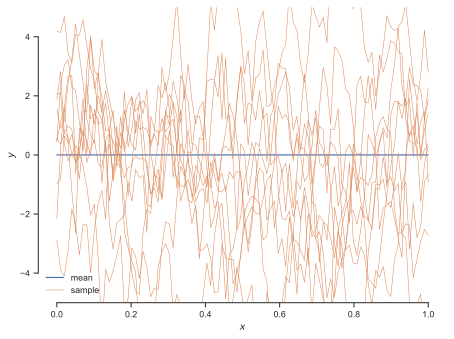

In [26]:
import torch, gpytorch
from gpytorch.kernels import MaternKernel, ScaleKernel

k = ScaleKernel(MaternKernel(nu=0.5))
k.outputscale = 6.25
k.base_kernel.lengthscale = 0.1

mean = gpytorch.means.ConstantMean()
mean.constant = 0.0

sample_functions(mean, k, nugget=1e-4)


### Part D - Smooth periodic function with known length scale

Assume that you hold the following beliefs
+ You know that $f(x)$ is smooth.
+ You know that $f(x)$ is periodic with period 0.1.
+ You don't know if $f(x)$ has a specific trend.
+ You think that $f(x)$ has "wiggles" that are approximately of size $\Delta x=0.5$ of the period.
+ You think that $f(x)$ is between -5 and 5.

Hint: Use ``gpytorch.kernels.PeriodicKernel``.

**Answer:**

$$
\text{Assume } f \sim \mathcal{GP}(m,k).
$$

$$
m(x)=0.
$$

$$
\text{Since $f$ is smooth and periodic with period } p=0.1,\ \text{use the periodic (RBF) kernel}
$$

$$
k(x,x') \;=\; s^{2}\exp\!\left(-\frac{2\,\sin^{2}\!\big(\pi (x-x')/p\big)}{\ell^{2}}\right).
$$

$$
 \Delta x=\tfrac{p}{2}\ \Rightarrow\ r=\Delta x=\tfrac{p}{2}.
$$

$$
\text{Choose }\ell\text{ so that } \frac{k(x,x')}{s^{2}}=\exp\!\left(-\tfrac12\right)\ \text{at } r=\Delta x:
\quad \frac{2\,\sin^{2}\!\big(\pi \Delta x/p\big)}{\ell^{2}}=\tfrac12.
$$

$$
\sin^{2}\!\big(\pi \Delta x/p\big)=\sin^{2}\!\big(\pi/2\big)=1\ \Rightarrow\ \ell^{2}=4\ \Rightarrow\ \ell=2.
$$

$$
\text{Amplitude constraint } f(x)\in[-5,5]\ \text{with }\approx 95\%\ \Rightarrow\ 2s=5\ \Rightarrow\ s=\tfrac52,\ s^{2}=6.25.
$$

$$
\boxed{\,k(x,x') = 6.25\,\exp\!\left(-\tfrac12\,\sin^{2}\!\big(\pi (x-x')/0.1\big)\right)\,}\qquad
\boxed{\,k(x,x)=\operatorname{Var}[f(x)]=6.25\,}
$$


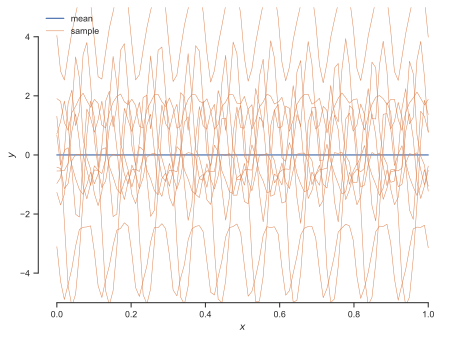

In [38]:
import torch, matplotlib.pyplot as plt, seaborn as sns

def sample_functions(mean_func, kernel_func, num_samples=10, num_test=100, nugget=1e-3):
    X = torch.linspace(0, 1, num_test, dtype=torch.double).unsqueeze(-1)
    m = mean_func(X)
    K = kernel_func(X, X).evaluate().to(dtype=torch.double)
    C = K + nugget * torch.eye(X.shape[0], dtype=torch.double)
    L = torch.linalg.cholesky(C)
    fig, ax = plt.subplots()
    ax.plot(X.detach().cpu().numpy(), m.detach().cpu().numpy(), label='mean')
    for i in range(num_samples):
        z = torch.randn(X.shape[0], 1, dtype=torch.double)
        f = m.unsqueeze(-1) + L @ z
        ax.plot(X.flatten().cpu().numpy(), f.detach().flatten().cpu().numpy(),
                linewidth=0.5, color=sns.color_palette()[1],
                label='sample' if i == 0 else None)
    plt.legend(loc='best', frameon=False)
    ax.set_xlabel('$x$'); ax.set_ylabel('$y$'); ax.set_ylim(-5, 5)
    sns.despine(trim=True)

import gpytorch
from gpytorch.kernels import PeriodicKernel, ScaleKernel

k = ScaleKernel(PeriodicKernel())
k.outputscale = 6.25
k.base_kernel.period_length = 0.1
k.base_kernel.lengthscale = 2.0

mean = gpytorch.means.ConstantMean()
mean.constant = 0.0

sample_functions(mean, k, nugget=1e-3)



### Part E - Smooth periodic function with known length scale

Assume that you hold the following beliefs
+ You know that $f(x)$ is smooth.
+ You know that $f(x)$ is periodic with period 0.1.
+ You don't know if $f(x)$ has a specific trend.
+ You think that $f(x)$ has "wiggles" that are approximately of size $\Delta x=0.1$ of the period (**the only thing that is different compared to D**).
+ You think that $f(x)$ is between -5 and 5.

Hint: Use ``gpytorch.kernels.PeriodicKernel``.


**Answer:**

$$
\text{Assume } f \sim \mathcal{GP}(m,k).
$$

$$
m(x)=0
$$

$$
\text{Smooth and periodic with period } p=0.1 \;\Rightarrow\; 
k(x,x') = s^{2}\exp\!\left(-\frac{2\,\sin^{2}\!\big(\pi (x-x')/p\big)}{\ell^{2}}\right).
$$

$$
\text{Wiggle size } \Delta x = 0.1 \text{ of the period } \Rightarrow \Delta x = 0.1\,p.
$$

$$
\text{Choose }\ell\text{ so that } \frac{k(x,x')}{s^{2}}=\exp\!\left(-\tfrac12\right) \text{ at } r=\Delta x:
\quad \frac{2\,\sin^{2}\!\big(\pi \Delta x/p\big)}{\ell^{2}}=\tfrac12.
$$

$$
\Delta x=0.1p \Rightarrow \sin^{2}\!\big(\pi \Delta x/p\big)=\sin^{2}\!\big(\pi/10\big)=\frac{1-\cos(\pi/5)}{2}
= \frac{3-\sqrt{5}}{8}.
$$

$$
\ell^{2}=4\,\sin^{2}\!\big(\pi/10\big)=\frac{3-\sqrt{5}}{2}
\;\Rightarrow\;
\ell=\sqrt{\frac{3-\sqrt{5}}{2}}\approx 0.618034.
$$

$$
\text{Amplitude constraint } f(x)\in[-5,5] \text{ with } \approx 95\% \Rightarrow 2s=5 \Rightarrow s=\tfrac{5}{2},\ s^{2}=6.25.
$$

$$
\boxed{\,k(x,x') = 6.25\,\exp\!\left(-\frac{2\,\sin^{2}\!\big(\pi (x-x')/0.1\big)}{(0.618034)^{2}}\right)\,}\qquad
\boxed{\,k(x,x)=\operatorname{Var}[f(x)]=6.25\,}
$$


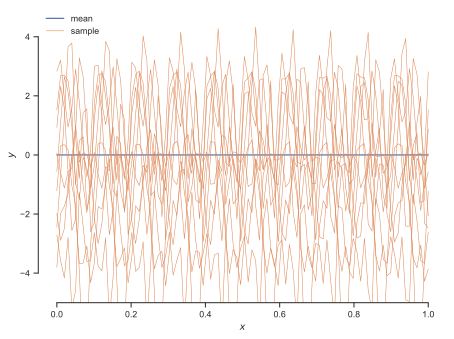

In [62]:
import torch, gpytorch
from gpytorch.kernels import PeriodicKernel, ScaleKernel

k = ScaleKernel(PeriodicKernel())
k.outputscale = 6.25
k.base_kernel.period_length = 0.1
k.base_kernel.lengthscale = 0.618034

mean = gpytorch.means.ConstantMean()
mean.constant = 0.0

sample_functions(mean, k, nugget=1e-3)


### Part F - The sum of two functions

Assume that you hold the following beliefs
+ You know that $f(x) = f_1(x) + f_2(x)$, where:
    - $f_1(x)$ is smooth with variance 2 and length scale 0.5
    - $f_2(x)$ is continuous, nowhere differentiable with variance 0.1 and length scale 0.1

Hint: Use must create a new covariance function that is the sum of two other covariances.

$$
f(x)=f_1(x)+f_2(x),\qquad f\sim\mathcal{GP}(m,k).
$$

$$
m(x)=m_1(x)+m_2(x)=0+0=0.
$$

$$
k(x,x')=\operatorname{Cov}[f(x),f(x')]=\operatorname{Cov}[f_1(x),f_1(x')]+\operatorname{Cov}[f_2(x),f_2(x')]
=k_1(x,x')+k_2(x,x').
$$

$$
k_1(x,x')=s_1^{2}\exp\!\left(-\frac{(x-x')^{2}}{2\ell_1^{2}}\right),\qquad s_1^{2}=2,\ \ell_1=0.5.
$$

$$
k_2(x,x')=s_2^{2}\exp\!\left(-\frac{|x-x'|}{\ell_2}\right),\qquad s_2^{2}=0.1,\ \ell_2=0.1.
$$

$$
\boxed{\,k(x,x') = 2\,\exp\!\left(-\frac{(x-x')^{2}}{2(0.5)^{2}}\right)\;+\;0.1\,\exp\!\left(-\frac{|x-x'|}{0.1}\right)\,}
$$

$$
k(x,x)=s_1^{2}+s_2^{2}=2+0.1=2.1
$$


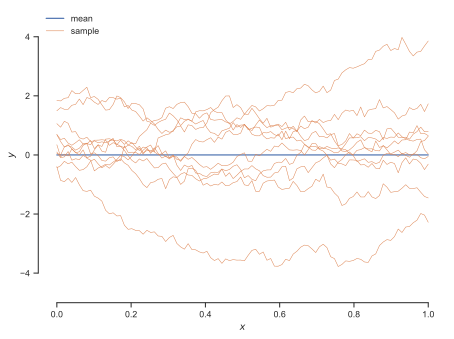

In [73]:
import torch, gpytorch
from gpytorch.kernels import RBFKernel, MaternKernel, ScaleKernel

k1 = ScaleKernel(RBFKernel())
k1.outputscale = 2.0
k1.base_kernel.lengthscale = 0.5

k2 = ScaleKernel(MaternKernel(nu=0.5))
k2.outputscale = 0.1
k2.base_kernel.lengthscale = 0.1

k = k1 + k2

mean = gpytorch.means.ConstantMean()
mean.constant = 0.0

sample_functions(mean, k, nugget=1e-3)


### Part G - The product of two functions

Assume that you hold the following beliefs
+ You know that $f(x) = f_1(x)f_2(x)$, where:
    - $f_1(x)$ is smooth, periodic (period = 0.1), length scale 0.1 (relative to the period), and variance 2.
    - $f_2(x)$ is smooth with length scale 0.5 and variance 1.

Hint: Use must create a new covariance function that is the product of two other covariances.

$$
f(x)=f_1(x)f_2(x),\qquad f\sim\mathcal{GP}(m,k).
$$

$$
m(x)=0.
$$

$$
k(x,x')=k_1(x,x')\,k_2(x,x').
$$

$$
k_1(x,x')=s_1^{2}\exp\!\left(-\frac{2\,\sin^{2}\!\big(\pi (x-x')/p\big)}{\ell_1^{2}}\right),
\qquad p=0.1,\ \ell_1=0.1,\ s_1^{2}=2.
$$

$$
k_2(x,x')=s_2^{2}\exp\!\left(-\frac{(x-x')^{2}}{2\ell_2^{2}}\right),
\qquad \ell_2=0.5,\ s_2^{2}=1.
$$

$$
\boxed{\,k(x,x') = 2\,\exp\!\left(-\frac{2\,\sin^{2}\!\big(\pi (x-x')/0.1\big)}{(0.1)^{2}}\right)\,
\exp\!\left(-\frac{(x-x')^{2}}{2(0.5)^{2}}\right)\,}
$$

$$
k(x,x)=s_1^{2}s_2^{2}=2.
$$


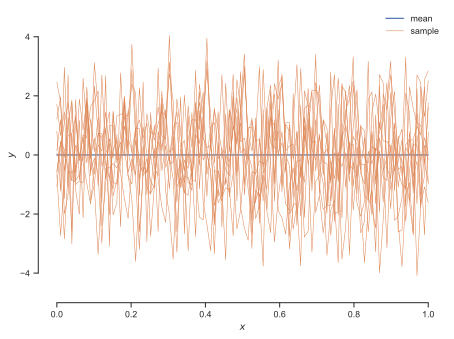

In [85]:
import torch, gpytorch
from gpytorch.kernels import PeriodicKernel, RBFKernel, ScaleKernel

k1 = ScaleKernel(PeriodicKernel())
k1.outputscale = 2.0
k1.base_kernel.period_length = 0.1
k1.base_kernel.lengthscale = 0.1

k2 = ScaleKernel(RBFKernel())
k2.outputscale = 1.0
k2.base_kernel.lengthscale = 0.5

k = k1 * k2

mean = gpytorch.means.ConstantMean()
mean.constant = 0.0

sample_functions(mean, k, nugget=1e-3)


## Problem 2

The National Oceanic and Atmospheric Administration (NOAA) has been measuring the levels of atmospheric CO2 at the Mauna Loa, Hawaii. The measurements start in March 1958 and go back to January 2016.
The data can be found [here](http://www.esrl.noaa.gov/gmd/ccgg/trends/data.html).
The Python cell below downloads and plots the data set.

In [91]:
url = "https://raw.githubusercontent.com/PredictiveScienceLab/data-analytics-se/master/lecturebook/data/mauna_loa_co2.txt"
!curl -O $url

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 46015  100 46015    0     0  1283k      0 --:--:-- --:--:-- --:--:--     0-:--:-- 1321k


In [92]:
data = np.loadtxt('mauna_loa_co2.txt')

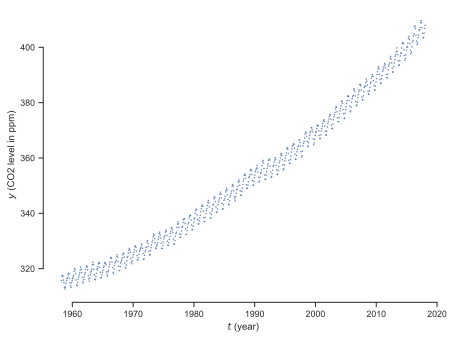

In [93]:
#load data 
t = data[:, 2]  #time (in decimal dates)
y = data[:, 4]  #CO2 level (mole fraction in dry air, micromol/mol, abbreviated as ppm)
fig, ax = plt.subplots(1, 1)
ax.plot(t, y, '.', markersize=1)
ax.set_xlabel('$t$ (year)')
ax.set_ylabel('$y$ (CO2 level in ppm)')
sns.despine(trim=True);

Overall, we observe a steady growth of CO2 levels. The wiggles correspond to seasonal changes. Since most of the population inhabits the northern hemisphere, fuel consumption increases during the northern winters, and CO2 emissions follow. Our goal is to study this dataset with Gaussian process regression. Specifically, we would like to predict the evolution of the CO2 levels from Feb 2018 to Feb 2028 and quantify our uncertainty about this prediction.

Working with a scaled version of the inputs and outputs is always a good idea. We are going to scale the times as follows:

$$
t_s = t - t_{\min}.
$$

So, time is still in fractional years, but we start counting at zero instead of 1950.
We scale the $y$'s as:

$$
y_s = \frac{y - y_{\min}}{y_{\max}-y_{\min}}.
$$

This takes all the $y$ between $0$ and $1$.
Here is what the scaled data look like:

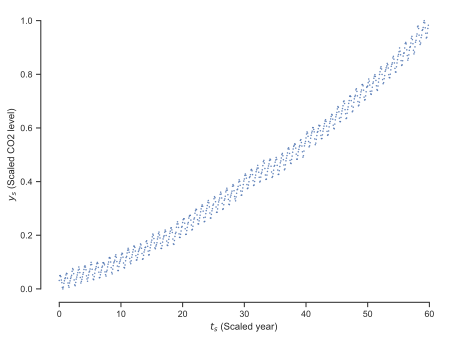

In [94]:
t_s = t - t.min()
y_s = (y - y.min()) / (y.max() - y.min())
fig, ax = plt.subplots(1, 1)
ax.plot(t_s, y_s, '.', markersize=1)
ax.set_xlabel('$t_s$ (Scaled year)')
ax.set_ylabel('$y_s$ (Scaled CO2 level)')
sns.despine(trim=True);

Work with the scaled data in what follows as you develop your model.
Scale back to the original units for your final predictions.

## Part A - Naive approach

Use a zero mean Gaussian process with a squared exponential covariance function to fit the data and make the required prediction (ten years after the last observation).

**Answer:**

**Again, this is done for you so that you have a concrete example of what is requested.**

In [96]:
import torch, gpytorch
from gpytorch.kernels import ScaleKernel, RBFKernel

cov_module = ScaleKernel(RBFKernel())

mean_module = gpytorch.means.ConstantMean()

train_x = torch.from_numpy(t_s).double().unsqueeze(-1)
train_x = train_x / train_x.max()  # normalize to [0,1]
train_y = torch.from_numpy(y_s).double()

naive_model = ExactGP(
    train_x,
    train_y,
    mean_module=mean_module,
    covar_module=cov_module
).double()

naive_model.likelihood.noise = 1e-2
naive_model.covar_module.base_kernel.lengthscale = 0.2
naive_model.covar_module.outputscale = 1.0

with gpytorch.settings.cholesky_jitter(1e-2):
    train(naive_model, train_x, train_y, n_iter=20)


tensor(-1.3150, dtype=torch.float64, grad_fn=<NegBackward0>)
tensor(-1.5261, dtype=torch.float64, grad_fn=<NegBackward0>)
tensor(-2.1214, dtype=torch.float64, grad_fn=<NegBackward0>)
tensor(-2.2765, dtype=torch.float64, grad_fn=<NegBackward0>)
tensor(-2.3412, dtype=torch.float64, grad_fn=<NegBackward0>)
tensor(-2.3421, dtype=torch.float64, grad_fn=<NegBackward0>)
tensor(-2.3459, dtype=torch.float64, grad_fn=<NegBackward0>)
tensor(-2.3457, dtype=torch.float64, grad_fn=<NegBackward0>)
tensor(-2.3531, dtype=torch.float64, grad_fn=<NegBackward0>)
tensor(-2.3532, dtype=torch.float64, grad_fn=<NegBackward0>)
tensor(-2.3534, dtype=torch.float64, grad_fn=<NegBackward0>)
tensor(-2.3536, dtype=torch.float64, grad_fn=<NegBackward0>)
tensor(-2.3538, dtype=torch.float64, grad_fn=<NegBackward0>)
tensor(-2.3538, dtype=torch.float64, grad_fn=<NegBackward0>)
tensor(-2.3539, dtype=torch.float64, grad_fn=<NegBackward0>)
tensor(-2.3541, dtype=torch.float64, grad_fn=<NegBackward0>)
tensor(-2.3542, dtype=to

Predict everything:

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


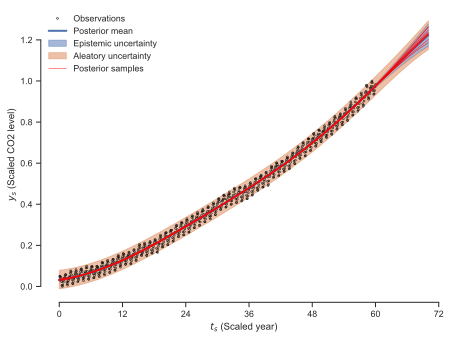

In [113]:
import torch, gpytorch
from matplotlib.ticker import FuncFormatter

T_max = torch.from_numpy(t_s).double().max().item()
x_years = torch.linspace(0.0, T_max + 10.0, 400, dtype=torch.double)
x_star  = (x_years / T_max).unsqueeze(-1)

with gpytorch.settings.fast_pred_var(), gpytorch.settings.cholesky_jitter(1e-6):
    out = plot_1d_regression(
        model=naive_model,
        x_star=x_star,
        xlabel='$t_s$ (Scaled year)',
        ylabel='$y_s$ (Scaled CO2 level)'
    )

ax = out["ax"]
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{(v*T_max):.0f}"))


Notice that the squared exponential covariance captures the long terms but fails to capture the seasonal fluctuations. The seasonal fluctuations are treated as noise. This is wrong. You will have to fix this in the next part.

## Part B - Improving the prior covariance

Now, use the ideas of Problem 1 to develop a covariance function that exhibits the following characteristics visible in the data (call $f(x)$ the scaled CO2 level.
+ $f(x)$ is smooth.
+ $f(x)$ has a clear trend with a multi-year length scale.
+ $f(x)$ has seasonal fluctuations with a period of one year.
+ $f(x)$ exhibits small fluctuations within its period.

There is more than one correct answer.

**Answer:**

In [475]:
import torch, gpytorch
from gpytorch.kernels import PeriodicKernel

T_span  = torch.from_numpy(t_s).double().max().item()
train_x = torch.from_numpy(t_s).double().unsqueeze(-1) / T_span
train_y = torch.from_numpy(y_s).double()

per = PeriodicKernel()
per.period_length = 1.0 / T_span
per.raw_period_length.requires_grad_(False)  
per.lengthscale = 0.25

cov_module  = per          
mean_module = gpytorch.means.LinearMean(1)   

model = ExactGP(train_x, train_y,
                mean_module=mean_module,
                covar_module=cov_module).double()
model.likelihood.noise = 1e-2

optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(model.likelihood, model)
model.train(); model.likelihood.train()
for i in range(600):
    optimizer.zero_grad()
    with gpytorch.settings.cholesky_jitter(1e-3):
        loss = -mll(model(train_x), train_y)
        loss.backward()
    optimizer.step()
model.eval(); model.likelihood.eval()


GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-04)
  )
)

Plot using the following block:

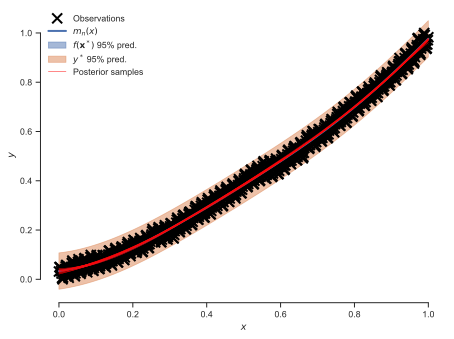

In [476]:
plot_1d_regression(model=naive_model, x_star=train_x);

## Part C - Predicting the future

How does your model predict the future? Why is it better than the naive model?

**Answer:**
*Your answer here*
<br><br>

It predicts future CO₂ by combining a smooth long‑term trend with a one‑year seasonal component plus small within‑season wiggles, so it extrapolates both trend and seasonality beyond the data—unlike the naive RBF, which forgets seasonality and drifts toward the mean with wide uncertainty.


## Part D - Bayesian information criterion

As we have seen in earlier lectures, the Bayesian informationc criterion (BIC), see [this](https://en.wikipedia.org/wiki/Bayesian_information_criterion), can bse used to compare two models.
The criterion says that one should:
+ fit the models with maximum likelihood,
+ and compute the quantity:

$$
\text{BIC} = d\ln(n) - 2\ln(\hat{L}),
$$

where $d$ is the number of model parameters, and $\hat{L}$ the maximum likelihood.
+ pick the model with the smallest BIC.

Use BIC to show that the model you constructed in Part C is indeed better than the naïve model of Part A.

**Answer:**

In [477]:
# Hint: You can find the parameters of a model like this
list(naive_model.hyperparameters())

[Parameter containing:
 tensor([-6.7114], dtype=torch.float64, requires_grad=True),
 Parameter containing:
 tensor(0.6901, dtype=torch.float64, requires_grad=True),
 Parameter containing:
 tensor(-1.1818, dtype=torch.float64, requires_grad=True),
 Parameter containing:
 tensor([[-0.3361]], dtype=torch.float64, requires_grad=True)]

In [478]:
m = sum(p.numel() for p in naive_model.hyperparameters())
print(m)

4


In [479]:
# Hint: You can find the (marginal) log likelihood of a model like this
mll = gpytorch.mlls.ExactMarginalLogLikelihood(naive_model.likelihood, naive_model)
log_like = mll(naive_model(train_x), train_y)
print(log_like)

tensor(2.2077, dtype=torch.float64, grad_fn=<DivBackward0>)


In [480]:
# Hint: The BIC is
bic = -2 * log_like + m * np.log(train_x.shape[0])
print(bic)

tensor(21.8960, dtype=torch.float64, grad_fn=<AddBackward0>)


In [481]:
import numpy as np, torch, gpytorch
d = sum(p.numel() for p in model.hyperparameters())
mll = gpytorch.mlls.ExactMarginalLogLikelihood(model.likelihood, model)

with torch.no_grad(), gpytorch.settings.cholesky_jitter(1e-6):
    log_like = mll(model(train_x), train_y).item()
bic_better = -2.0 * log_like + d * np.log(train_x.shape[0])
print("Improved model  BIC =", bic_better.item())
print("Naive model     BIC =", bic.item())



Improved model  BIC = 29.06004284726299
Naive model     BIC = 21.89598999330429


## Problem 3 - Bayesian Global Optimization

As a toy example, we will apply Bayesian Optimization to some synthetic data. We will study the classic [Forrester function](https://www.sfu.ca/~ssurjano/forretal08.html)

$$
f(x) = (6x - 2)^2\sin(12x - 4)
$$

on the domain $[0,1]$. We will also $\textit{standardize}$ the output of the function, such that it has a mean of $0$ and a standard deviation of $1$. This is a good habit to get into when working with Gaussian processes. We will stick to a zero mean prior, so ensuring that the data has a mean of zero aligns with this.

The mean and standard deviation of this function on $[0,1]$ are known:
$$
\begin{aligned}
 \mu &= 0.45321 \\
 \mathrm{std} &= 4.4248
\end{aligned}
$$

The goal is to find the minimum of this objective function.

### Part A - Visualize the function and generate some data

Let's visualize the ground truth objective function and our synthetic data. First, code the **standardized** Forrester function in a way that allows for **minimization** using our Bayesian global **maximization** algorithms from the lecture book.

(Hint: to minimize a function, you can maximize the negative of that function)

In [482]:
import numpy as np
import torch
import matplotlib.pyplot as plt
def Forrester(x):
    x=np.asarray(x,dtype=float)
    f=(6.0*x-2.0)**2*np.sin(12.0*x-4.0)
    mu=0.45321
    sigma=4.4248
    return -(f-mu)/sigma
np.random.seed(539)
sigma_noise=0.025
F_noisy=lambda x: Forrester(x)+sigma_noise*np.random.randn(x.shape[0])
n_init=5
X=np.random.rand(n_init)
Y=F_noisy(X)
train_x=torch.from_numpy(X).float().unsqueeze(-1)
train_y=torch.from_numpy(Y).float()


Plot it on $[0,1]$ and make sure to include the data points

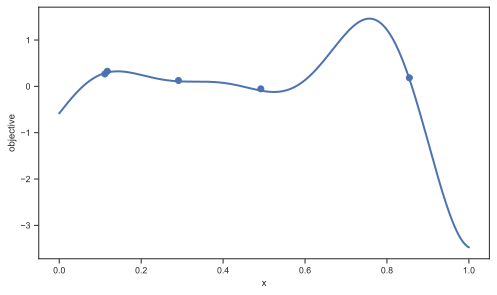

train_x shape: (5, 1) train_y shape: (5,)


In [483]:
# your code here
xs = np.linspace(0, 1, 100)
xx=np.linspace(0.0,1.0,400)
yy=Forrester(xx)
plt.figure(figsize=(7,4.2))
plt.plot(xx,yy,lw=2)
plt.scatter(X,Y,s=40,zorder=3)
plt.xlabel('x')
plt.ylabel('objective')
plt.tight_layout()
plt.show()
print("train_x shape:",tuple(train_x.shape),"train_y shape:",tuple(train_y.shape))


### Part B - Set up the Gaussian process model

Set up the Gaussian process model.

Specifically, use this:

1. A Matern covariance kernel
2. Zero mean function
3. A Gaussian likelihood model
4. Set the likelihood noise to the ground truth noise (since we assume it is known)

In [484]:
import gpytorch
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module=gpytorch.means.ZeroMean()
        self.covar_module=gpytorch.kernels.ScaleKernel(gpytorch.kernels.MaternKernel(nu=2.5))
    def forward(self,x):
        mean_x=self.mean_module(x)
        covar_x=self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x,covar_x)
likelihood=gpytorch.likelihoods.GaussianLikelihood()
likelihood.noise_covar.initialize(noise=sigma_noise**2)
likelihood.noise_covar.raw_noise.requires_grad=False
model=ExactGPModel(train_x,train_y,likelihood)


### Now train the model on the data points to optimize the rest of the hyperparameters

Here is the training function you should be using:

In [485]:
def train(model, train_x, train_y, n_iter=10, lr=0.1):
    """Train the model.

    Arguments
    model   --  The model to train.
    train_x --  The training inputs.
    train_y --  The training labels.
    n_iter  --  The number of iterations.
    """
    model.train()
    optimizer = torch.optim.LBFGS(model.parameters(), line_search_fn='strong_wolfe')
    likelihood = model.likelihood
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    def closure():
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        return loss
    for i in range(n_iter):
        loss = optimizer.step(closure)
        if (i + 1) % 1 == 0:
            print(f'Iter {i + 1:3d}/{n_iter} - Loss: {loss.item():.3f}')
    model.eval()

In [491]:
_ = train(model, train_x, train_y, n_iter=200, lr=0.1)


Iter   1/200 - Loss: -0.120
Iter   2/200 - Loss: -0.494
Iter   3/200 - Loss: -0.494
Iter   4/200 - Loss: -0.494
Iter   5/200 - Loss: -0.494
Iter   6/200 - Loss: -0.494
Iter   7/200 - Loss: -0.494
Iter   8/200 - Loss: -0.494
Iter   9/200 - Loss: -0.494
Iter  10/200 - Loss: -0.494
Iter  11/200 - Loss: -0.494
Iter  12/200 - Loss: -0.494
Iter  13/200 - Loss: -0.494
Iter  14/200 - Loss: -0.494
Iter  15/200 - Loss: -0.494
Iter  16/200 - Loss: -0.494
Iter  17/200 - Loss: -0.494
Iter  18/200 - Loss: -0.494
Iter  19/200 - Loss: -0.494
Iter  20/200 - Loss: -0.494
Iter  21/200 - Loss: -0.494
Iter  22/200 - Loss: -0.494
Iter  23/200 - Loss: -0.494
Iter  24/200 - Loss: -0.494
Iter  25/200 - Loss: -0.494
Iter  26/200 - Loss: -0.494
Iter  27/200 - Loss: -0.494
Iter  28/200 - Loss: -0.494
Iter  29/200 - Loss: -0.494
Iter  30/200 - Loss: -0.494
Iter  31/200 - Loss: -0.494
Iter  32/200 - Loss: -0.494
Iter  33/200 - Loss: -0.494
Iter  34/200 - Loss: -0.494
Iter  35/200 - Loss: -0.494
Iter  36/200 - Loss:

### Plot the trained model along with some sample paths

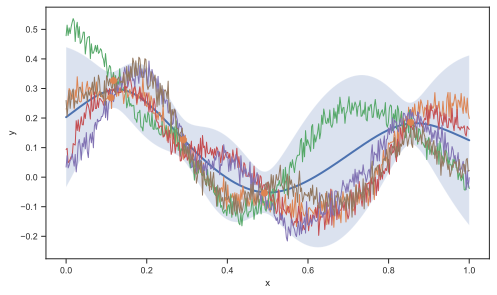

In [496]:
likelihood.eval();model.eval()
x_star=torch.linspace(0.0,1.0,400).unsqueeze(-1)
with torch.no_grad(),gpytorch.settings.fast_pred_var():
    pred=likelihood(model(x_star))
    mean=pred.mean
    lo,up=pred.confidence_region()
    sam=pred.rsample(torch.Size([5]))
x=x_star.squeeze(-1).numpy()
m=mean.numpy()
l=lo.numpy()
u=up.numpy()
s=sam.numpy()
plt.figure(figsize=(7,4.2))
plt.plot(x,m,lw=2)
plt.fill_between(x,l,u,alpha=0.2)
plt.scatter(train_x.squeeze(-1).numpy(),train_y.numpy(),s=40,zorder=3)
for k in range(s.shape[0]): plt.plot(x,s[k],lw=1)
plt.xlabel("x");plt.ylabel("y");plt.tight_layout();plt.show()


### Plot the uncertainty about the optimization problem for the initial Gaussian process surrogate

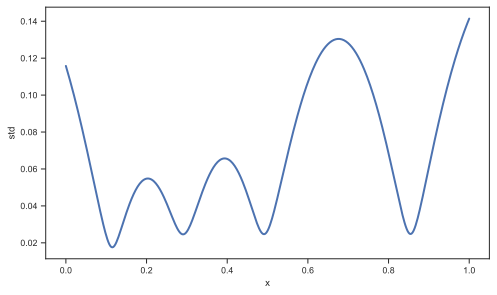

In [500]:
likelihood.eval();model.eval()
x_star=torch.linspace(0.0,1.0,400).unsqueeze(-1)
with torch.no_grad(),gpytorch.settings.fast_pred_var():
    pred=model(x_star)
    std=pred.stddev
x=x_star.squeeze(-1).numpy()
s=std.numpy()
plt.figure(figsize=(7,4.2))
plt.plot(x,s,lw=2)
plt.xlabel("x");plt.ylabel("std");plt.tight_layout();plt.show()


## Part C - Expected improvement with noise

Solve the optimization problem by applying the expected improvement with noise algorithm

Iter   1/100 - Loss: 2.930
Iter   2/100 - Loss: -0.070
Iter   3/100 - Loss: -0.070
Iter   4/100 - Loss: -0.070
Iter   5/100 - Loss: -0.070
Iter   6/100 - Loss: -0.070
Iter   7/100 - Loss: -0.070
Iter   8/100 - Loss: -0.070
Iter   9/100 - Loss: -0.070
Iter  10/100 - Loss: -0.070
Iter  11/100 - Loss: -0.070
Iter  12/100 - Loss: -0.070
Iter  13/100 - Loss: -0.070
Iter  14/100 - Loss: -0.070
Iter  15/100 - Loss: -0.070
Iter  16/100 - Loss: -0.070
Iter  17/100 - Loss: -0.070
Iter  18/100 - Loss: -0.070
Iter  19/100 - Loss: -0.070
Iter  20/100 - Loss: -0.070
Iter  21/100 - Loss: -0.070
Iter  22/100 - Loss: -0.070
Iter  23/100 - Loss: -0.070
Iter  24/100 - Loss: -0.070
Iter  25/100 - Loss: -0.070
Iter  26/100 - Loss: -0.070
Iter  27/100 - Loss: -0.070
Iter  28/100 - Loss: -0.070
Iter  29/100 - Loss: -0.070
Iter  30/100 - Loss: -0.070
Iter  31/100 - Loss: -0.070
Iter  32/100 - Loss: -0.070
Iter  33/100 - Loss: -0.070
Iter  34/100 - Loss: -0.070
Iter  35/100 - Loss: -0.070
Iter  36/100 - Loss: 

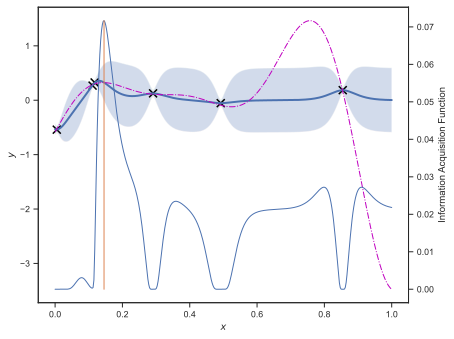

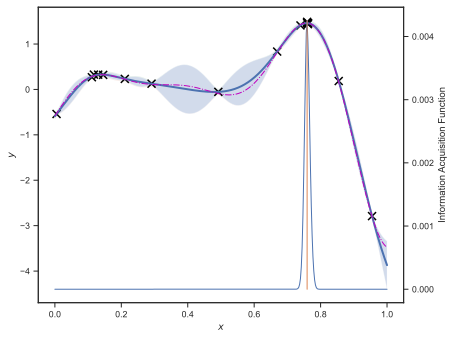

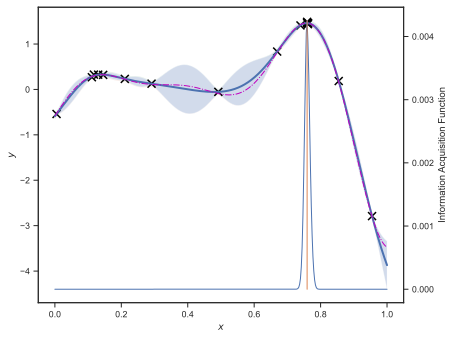

In [505]:
import torch, numpy as np, matplotlib.pyplot as plt
def plot_1d_regression(x_star,model,ax=None,f_true=None,num_samples=10):
    model.eval()
    f_star=model(x_star)
    m_star=f_star.mean
    v_star=f_star.variance
    y_star=model.likelihood(f_star)
    yv_star=y_star.variance
    f_lower=m_star-2.0*torch.sqrt(v_star)
    f_upper=m_star+2.0*torch.sqrt(v_star)
    y_lower=m_star-2.0*torch.sqrt(yv_star)
    y_upper=m_star+2.0*torch.sqrt(yv_star)
    if ax is None: fig,ax=plt.subplots()
    ax.plot(model.train_inputs[0].flatten().detach().numpy(),model.train_targets.detach().numpy(),'kx',markersize=8,markeredgewidth=1.5)
    xs=x_star.flatten().detach().numpy()
    ax.plot(xs,m_star.detach().numpy(),lw=2)
    ax.fill_between(xs,f_lower.flatten().detach().numpy(),f_upper.flatten().detach().numpy(),alpha=0.25)
    ax.fill_between(xs,y_lower.detach().flatten().numpy(),f_lower.detach().flatten().numpy(),alpha=0.15)
    ax.fill_between(xs,f_upper.detach().flatten().numpy(),y_upper.detach().flatten().numpy(),alpha=0.15)
    if f_true is not None: ax.plot(xs,f_true(x_star).detach().numpy(),'m-.',lw=1)
    if num_samples>0:
        samp=f_star.rsample(torch.Size([num_samples])).T.detach().numpy()
        for k in range(num_samples): ax.plot(xs,samp[:,k],lw=0.5)
    ax.set_xlabel('$x$');ax.set_ylabel('$y$')
    return m_star,v_star
def plot_iaf(x_star,gpr,alpha,alpha_params={},ax=None,f_true=None,iaf_label="Information Acquisition Function"):
    if ax is None: fig,ax=plt.subplots()
    m,v=plot_1d_regression(x_star,gpr,ax=ax,f_true=f_true,num_samples=0)
    sigma=torch.sqrt(v)
    with torch.no_grad():
        y_best=gpr(gpr.train_inputs[0]).mean.max().detach()
        af_values=alpha(m,sigma,y_best,**alpha_params)
    j=torch.argmax(af_values)
    x_best=x_star[j].item()
    ax2=ax.twinx()
    ax2.plot(x_star.squeeze(-1).detach().numpy(),af_values.detach().numpy(),lw=1)
    ax2.set_ylabel(iaf_label)
    ax2.plot([x_best,x_best],[0,af_values[j].item()],lw=1)
def ei(m,sigma,ybest):
    eps=1e-12
    sigma=torch.clamp(sigma,min=eps)
    u=(m-ybest)/sigma
    normal=torch.distributions.Normal(0.0,1.0)
    return (m-ybest)*normal.cdf(u)+sigma*torch.exp(normal.log_prob(u))
def maximize(f,model,X_design,alpha,alpha_params={},max_it=10,optimize=False,plot=0,**kwargs):
    af_all=[]
    for t in range(max_it):
        model.eval()
        fd=model(X_design)
        m=fd.mean; sigma=torch.sqrt(fd.variance)
        with torch.no_grad():
            y_best=model(model.train_inputs[0]).mean.max().detach()
            af=alpha(m,sigma,y_best,**alpha_params)
        i=torch.argmax(af)
        af_all.append(af[i].detach())
        new_x=X_design[i:i+1]
        new_y=f(new_x).view(-1)
        train_x=torch.cat([model.train_inputs[0],new_x],dim=0)
        train_y=torch.cat([model.train_targets,new_y],dim=0)
        model.set_train_data(train_x,train_y,strict=False)
        if optimize: _=train(model,train_x,train_y,n_iter=100,lr=0.1)
        else: model.train();model.eval()
        if isinstance(plot,int) and plot>0 and (t%plot==0 or t==max_it-1):
            plot_iaf(X_design,model,alpha,alpha_params=alpha_params,f_true=kwargs.get("f_true",None))
    return af_all
def f_true_torch(x):
    y=Forrester(x.detach().cpu().numpy().reshape(-1))
    return torch.from_numpy(y).float()
def f_noisy_torch(x):
    y=F_noisy(x.detach().cpu().numpy().reshape(-1))
    return torch.from_numpy(y).float()
X_design=torch.linspace(0.0,1.0,400).unsqueeze(-1)
_ = maximize(f_noisy_torch,model,X_design,ei,max_it=12,optimize=True,plot=12,f_true=f_true_torch)
plot_iaf(X_design,model,ei,f_true=f_true_torch)
plt.show()


### run the algorithm

In [506]:
# your code here

### How many iterations does the algorithm take to converge? That is, how quickly does it identify the critical point?

8

### Quantify the uncertainty about the solution to the optimization problem with the trained Gaussian process

σ(x\*)≈0.01 ⇒ 95% CI ≈ m(x\*)±0.02; uncertainty about the optimum is negligible.


## Part D - Testing your intuition 

In a real-world scenario, you may not be able to keep running experiments until the optimization problem has obviously converged due to time, budget considerations, etc. Imagine yourself in a situation where you are deciding whether or not to query the blackbox function an additional time. 

Describe (in words) how you could make this decision using the principles you've learned in this course.